In [19]:
import ollama 
import os
from tqdm import tqdm
import json
import signal
import argparse
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import copy

import sys
from collections import defaultdict

#from  utilities import *

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

In [21]:
list_of_models = ['llava:7b', 'llava:13b', 'llava:34b', 'llama3.2-vision:90b']

In [22]:
sys.argv = [
    'notebook',  
    '--modelname', 'llama3.2-vision:90b',
    '--data', 'gully',
    '--data_path','/home/data/',
    "--data_samples", 'train.jsonl',
    "--subset", 'train',
    '--results_dir', '/root/home/WACV-2025-Workshop-ViGIR/results/proposed',
    '--timeout', '20',
    '--model_unloading'
]

In [23]:
parser = argparse.ArgumentParser(description="A script to run V-LLMs on different image classification datasets")

In [24]:
# set up the argument parser
parser.add_argument("--modelname", type=str, required=True, help="The name of the V-LLM model")
parser.add_argument("--data", type=str, required=True, help="Dataset name")
parser.add_argument("--data_path", type=str, required=True, help="Path to the image data dir")
parser.add_argument("--data_samples", type=str, required=True, help="Name of the samples to run on")
parser.add_argument("--subset", type=str, required=True, help="train, test or validation set")
parser.add_argument("--results_dir", type=str, required=True, help="Folder name to save results")
parser.add_argument("--timeout", type=int, default=40, help="time out duration to skip one sample")
parser.add_argument("--model_unloading", action="store_true", help="Enables unloading mode. Every 100 sampels it unloades the model from the GPU to avoid carshing.")


args = parser.parse_args()

In [25]:
# Set up the wandb run 
#run = wandb.init(
#    entity="jacketdembys",
#    project=f"wacv-2025-{args.data}",
#    name="run_test_" + args.data+"-"+args.modelname+"-"+args.subset
#)

In [26]:
# Create a result folder
print(args.results_dir)
if not os.path.exists(args.results_dir):
    os.makedirs(args.results_dir)

/root/home/WACV-2025-Workshop-ViGIR/results/proposed


In [27]:
# Load test set:
file_path = 'Testing_Set.json'
#file_path = 'Validation_Set.json'
with open(file_path, 'r') as file:
    data = json.load(file)

print('Number of Annotated GT Images: ', len(data.keys()))
data_keys_test = list(data.keys())
print('Number of Annotated GT Images (List): ', len(data_keys_test))

Number of Annotated GT Images:  311
Number of Annotated GT Images (List):  311


In [28]:
# Load the images
# directory = '/root/home/data_jpg'
# tile_dict = defaultdict(list)

# for filename in os.listdir(directory):
#     if filename.endswith('.jpg'):
#         parts = filename.split('_')
#         tile_number = parts[4].split('.')[0]
#         tile_dict[tile_number].append(os.path.join(directory,filename))

# tile_dict = dict(tile_dict)

# print("Total number of tiles: {}".format(len(tile_dict.keys())))

In [29]:
# Load the images
directory = '/root/home/data'
tile_dict = defaultdict(list)

for filename in os.listdir(directory):
    if filename.endswith('.jpg'):
        parts = filename.split('_')
        tile_number = parts[2].split('.')[0]
        tile_dict[tile_number].append(os.path.join(directory,filename))

tile_dict = dict(tile_dict)

print("Total number of tiles: {}".format(len(tile_dict.keys())))

Total number of tiles: 900


In [30]:
tile_dict

{'100': ['/root/home/data/neg_collage_100.jpg'],
 '1000': ['/root/home/data/neg_collage_1000.jpg'],
 '1001': ['/root/home/data/neg_collage_1001.jpg'],
 '1002': ['/root/home/data/neg_collage_1002.jpg'],
 '1003': ['/root/home/data/neg_collage_1003.jpg'],
 '1004': ['/root/home/data/neg_collage_1004.jpg'],
 '1005': ['/root/home/data/neg_collage_1005.jpg'],
 '1006': ['/root/home/data/neg_collage_1006.jpg'],
 '1007': ['/root/home/data/neg_collage_1007.jpg'],
 '1009': ['/root/home/data/neg_collage_1009.jpg'],
 '101': ['/root/home/data/neg_collage_101.jpg'],
 '1010': ['/root/home/data/neg_collage_1010.jpg'],
 '1011': ['/root/home/data/neg_collage_1011.jpg'],
 '1013': ['/root/home/data/neg_collage_1013.jpg'],
 '1014': ['/root/home/data/neg_collage_1014.jpg'],
 '1015': ['/root/home/data/neg_collage_1015.jpg'],
 '1017': ['/root/home/data/neg_collage_1017.jpg'],
 '1018': ['/root/home/data/neg_collage_1018.jpg'],
 '1019': ['/root/home/data/neg_collage_1019.jpg'],
 '102': ['/root/home/data/neg_colla

In [31]:
#for tile_number, file_list in tile_dict.items():
#    tile_dict[tile_number] = sorted(file_list, key=lambda x: int(x.split('_')[3]))

In [32]:
tile_dict_val = {}
for tile_number, file_list in tile_dict.items():
    if tile_number in data_keys_test:
        #tile_dict[tile_number] = sorted(file_list, key=lambda x: int(x.split('_')[2]))
        tile_dict_val[tile_number] = file_list

In [33]:
#unwanted_patterns = ['rgb_0', 'rgb_2', 'rgb_4']

In [34]:
#data = {key: [path for path in paths if not any(sub in path for sub in unwanted_patterns)] 
#        for key, paths in tile_dict.items()}

In [35]:
data = copy.deepcopy(tile_dict_val)
print('Number of collage in set: ', len(tile_dict_val))

Number of collage in set:  311


In [36]:
print(data)

{'100': ['/root/home/data/neg_collage_100.jpg'], '1004': ['/root/home/data/neg_collage_1004.jpg'], '1005': ['/root/home/data/neg_collage_1005.jpg'], '1007': ['/root/home/data/neg_collage_1007.jpg'], '1010': ['/root/home/data/neg_collage_1010.jpg'], '1015': ['/root/home/data/neg_collage_1015.jpg'], '1017': ['/root/home/data/neg_collage_1017.jpg'], '1018': ['/root/home/data/neg_collage_1018.jpg'], '1020': ['/root/home/data/neg_collage_1020.jpg'], '1021': ['/root/home/data/neg_collage_1021.jpg'], '1031': ['/root/home/data/neg_collage_1031.jpg'], '1032': ['/root/home/data/neg_collage_1032.jpg'], '1035': ['/root/home/data/neg_collage_1035.jpg'], '1038': ['/root/home/data/neg_collage_1038.jpg'], '104': ['/root/home/data/neg_collage_104.jpg'], '1040': ['/root/home/data/neg_collage_1040.jpg'], '1041': ['/root/home/data/neg_collage_1041.jpg'], '1043': ['/root/home/data/neg_collage_1043.jpg'], '1049': ['/root/home/data/neg_collage_1049.jpg'], '105': ['/root/home/data/neg_collage_105.jpg'], '1050

In [39]:
"""
questions = [
    "Across the images, do you see a low point in the terrain where a temporary gully or depression begins to form without a permanent water feature? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do narrow, winding paths or channels appear and become more defined across the sequence? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Over time, do any linear depressions or ruts become more pronounced along natural drainage lines or slopes? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Does a narrow, shallow channel become visibly deeper or more indented into the soil over the image sequence? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there areas where soil appears disturbed or vegetation is removed, showing progression over the images? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Across the sequence, does a specific path lack vegetation, suggesting an evolving or emerging channel? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Does the texture of the soil appear to change, becoming coarser or showing small pebbles in areas that develop into channels? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Can you see any clear starting and ending points for these channels becoming more evident over time? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do small rills or grooves indicating water flow appear or deepen across the images? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Is there a gradual exposure of lighter-colored soil as the gully forms? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there sediment accumulations forming at the lower ends of channels as time progresses? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Across the images, do signs of water activity, like soil clumps or crusting, appear or intensify in specific areas? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do shallow side walls along the channel areas become more defined as the sequence progresses? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do deposits of silt or small debris appear and accumulate along any emerging channel paths? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Can you observe branching patterns that resemble temporary streams forming or intensifying over time? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Do areas with compacted soil or minor slope collapse become more noticeable along the developing channel edges? Please answer with YES or NO Only. DO NOT mention the reason.",
    "Are there indications of nearby human activity, such as tillage or machinery tracks, influencing the formation or expansion of these channels? Please answer with YES or NO Only. DO NOT mention the reason."
]
"""

#questions = ["Given a collage image of six distinct photos. How many distinct photos do you see in the provided collage image? Your answer should only include the number of photos and nothing else."]
#questions = ["Given a collage of six images. How many images do you see in the provided collage? Your answer should only include the number of photos and nothing else."]
#questions = ["Given this collage of six images. How many images do you see in the provided collage? Your output must just include the number of images and nothing else."]
#questions = ["Given this collage of six images of the exact same area, collected over a period of 10 years. Are there any ephemeral gully appearances? Answer by Yes or No and nothing else."]

#questions = ["Given this collage of six images of the exact same area, collected over a period of 10 years. Analyze these collages and provide a definitive conclusion without needing more information to the following question and not just a list of steps: \n Question: are there any ephemeral gully appearances by looking at all of them together? "]
#questions = ["Given this collage of six images of the exact same area, collected over a period of 10 years. Are there any ephemeral gully appearances by looking at all of them together?. Reason and conclude with only yes or no. "]


questions = [
    "Given these six images of the exact same area and collected over a period of 10 years, do you see a low point in the terrain? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, do narrow, winding paths or channels appear?  Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there winding paths that become intermittent recurrent?  Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there any linear depressions or ruts which appear more pronounced along natural drainage lines or slopes?  Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there narrow and shallow channels which appear intermittently deeper or more indented into the soil?  Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there areas where soil appears disturbed or vegetation is removed?  Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, does a specific path lack vegetation, suggesting an evolving or emerging channel? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there varying types and levels of coarseness in the texture of the soil? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there clear starting and ending points of potential channels? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there small rills or grooves indicating water flow? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, is there a varying exposure of lighter or darker colored soil? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there sediment accumulations forming? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there signs of water activity, like soil clumps or crusting, that appear or intensify in specific areas? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there any branching patterns that resemble temporary streams? Provide the reason.",
    "Given these six images of the exact same area and collected over a period of 10 years, are there indications of nearby human activity, such as tillage or machinery tracks? Provide the reason."
]



In [40]:
model_name = args.modelname
ollama.pull(model_name)

timeout_duration = args.timeout

options= {  # new
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048, # must be set, otherwise slightly random output
        }

model_labels = {}
count = 0

In [ ]:
count = 0
saving_response=dict(tile_dict_val.copy())

for key, info in tqdm(data.items()):

    #print(key)
    #print(info)
    
    count+=1
    for question in questions:
        response = ollama.generate(model=model_name, 
                                   prompt=question, 
                                   images=info, 
                                   options=options)
        saving_response[key].append(response['response'])
        print(response['response'])

        #sys.exit()
        
       
    

  0%|                                                                                                              | 0/311 [00:00<?, ?it/s]

**Step 1: Analyze the images for signs of water accumulation or flooding.**

*   The images show no visible signs of water accumulation or flooding.

**Step 2: Look for areas with different vegetation patterns or colors that could indicate a low point in the terrain.**

*   There are no noticeable differences in vegetation patterns or colors across the images.

**Conclusion:** 

Based on the analysis, there is no indication of a low point in the terrain from these six images collected over 10 years.
No, there are no narrow, winding paths or channels in any of the images. The images show dense forest cover with no visible signs of human-made features such as roads, trails, or waterways. The consistent green coloration across all six images suggests that the area has remained largely unchanged over the 10-year period, with no evidence of deforestation, land use changes, or other disturbances that might have created paths or channels.
To determine if there are winding paths that become in

  0%|▎                                                                                                 | 1/311 [06:38<34:21:26, 398.99s/it]

**Step 1: Analyze the images for signs of human activity**

*   The images show a forested area with no visible signs of human activity such as tillage or machinery tracks.
*   There are no clearings, roads, or other infrastructure that would indicate nearby human presence.

**Step 2: Consider alternative explanations for changes in vegetation**

*   Changes in vegetation could be due to natural factors such as climate change, disease outbreaks, or insect infestations rather than human activity.
*   The images do not provide enough information to determine the cause of any changes in vegetation.

**Conclusion:**

Based on the analysis, there are no indications of nearby human activity such as tillage or machinery tracks in the provided images.
To determine if there is a low point in the terrain based on the provided images, we need to analyze each image for signs that could indicate such a feature. 

Low points or depressions in the landscape often collect water and can be identified b

  1%|▋                                                                                                 | 2/311 [11:24<28:29:37, 331.97s/it]

...

**Step 1: Analyze the images for signs of human activity**

*   The images show no visible signs of tillage or machinery tracks.
*   There are no changes in vegetation patterns that could indicate human intervention.

**Step 2: Consider alternative explanations for observed features**

*   Natural processes such as erosion, weathering, and plant growth can cause changes in the landscape without human involvement.
*   The images do not provide conclusive evidence of nearby human activity.

**Conclusion:**

Based on the analysis, there are no indications of nearby human activity, such as tillage or machinery tracks, in these six images.
**Step 1: Analyze the images for signs of water accumulation or flooding.**

Looking at the images, there are no visible signs of water accumulation or flooding.

**Step 2: Check for vegetation growth patterns that could indicate a low point in the terrain.**

The vegetation growth patterns do not show any significant differences across the area.

**Step 

 97%|████████████████████████████████████████████████████████████████████████████████████████████▉   | 301/311 [22:03:02<45:22, 272.25s/it]

**Step 1: Analyze the images for signs of human activity**

*   The images show no visible signs of tillage or machinery tracks.
*   There are no linear features that could indicate the presence of roads or trails.

**Step 2: Consider alternative explanations for the lack of human activity**

*   It is possible that the area has not been used for agriculture or other human activities in recent years.
*   The images may have been taken during a time when the area was not being actively managed or maintained.

**Conclusion:**

Based on the analysis, there are no indications of nearby human activity such as tillage or machinery tracks.
**Step 1: Analyze the images for any visual cues indicating a low point in the terrain.**

Looking at the images, there are no obvious visual cues such as shadows or water accumulation that would indicate a low point in the terrain.

**Step 2: Check for any changes in vegetation or land use over time that could suggest a low-lying area.**

There are no noti

 97%|█████████████████████████████████████████████████████████████████████████████████████████████▏  | 302/311 [22:07:34<40:50, 272.32s/it]

**Step 1: Analyze the images for signs of human activity**

*   The images show no visible signs of tillage or machinery tracks.
*   There are no linear features that could indicate the presence of roads or trails.

**Step 2: Consider alternative explanations for the lack of human activity**

*   It is possible that the area has not been used for agriculture or other human activities in recent years.
*   The images may have been taken during a time when there was little to no human activity in the area.

**Conclusion:**

Based on the analysis, there are no indications of nearby human activity such as tillage or machinery tracks.
**Step 1: Analyze the images for signs of water accumulation or flooding.**

Looking at the images, there are no visible signs of water accumulation or flooding.

**Step 2: Check for vegetation growth patterns that could indicate a low point in the terrain.**

The images do not show any distinct vegetation growth patterns that would suggest a low point in the t

In [22]:
print(info)
image_file = info[0]
print()
print(image_file)
img = Image.open(image_file)

['/root/home/data/pos_collage_991.jpg']

/root/home/data/pos_collage_991.jpg


UnidentifiedImageError: cannot identify image file '/root/home/data/pos_collage_991.jpg'

In [23]:
pwd

'/mnt/jacket/WACV-2025-Workshop-ViGIR'

In [24]:
list(saving_response.keys())

['100',
 '1004',
 '1005',
 '1007',
 '1010',
 '1015',
 '1017',
 '1018',
 '1020',
 '1021',
 '1031',
 '1032',
 '1035',
 '1038',
 '104',
 '1040',
 '1041',
 '1043',
 '1049',
 '105',
 '1050',
 '1051',
 '1053',
 '1062',
 '1064',
 '1065',
 '1067',
 '107',
 '1073',
 '1078',
 '1081',
 '1085',
 '1095',
 '1098',
 '1099',
 '1114',
 '1117',
 '1121',
 '1123',
 '1128',
 '1133',
 '1137',
 '1138',
 '1140',
 '1141',
 '1143',
 '117',
 '118',
 '123',
 '124',
 '125',
 '126',
 '128',
 '129',
 '131',
 '135',
 '248',
 '250',
 '251',
 '253',
 '266',
 '267',
 '272',
 '273',
 '287',
 '288',
 '289',
 '301',
 '306',
 '310',
 '312',
 '316',
 '319',
 '320',
 '322',
 '331',
 '334',
 '335',
 '337',
 '343',
 '344',
 '454',
 '458',
 '471',
 '473',
 '474',
 '475',
 '476',
 '478',
 '485',
 '486',
 '502',
 '505',
 '511',
 '513',
 '515',
 '519',
 '520',
 '521',
 '522',
 '529',
 '532',
 '70',
 '71',
 '732',
 '739',
 '74',
 '740',
 '742',
 '748',
 '752',
 '758',
 '759',
 '761',
 '766',
 '774',
 '784',
 '788',
 '789',
 '794',
 

In [25]:
print(saving_response)

{'100': ['/root/home/data/neg_collage_100.jpg', 'To determine if there are any ephemeral gully appearances in the collage of six images, we need to analyze each image carefully. \n\nEphemeral gullies are small channels that form on hillslopes due to surface runoff and can be an indicator of soil erosion. They typically appear as narrow, shallow depressions or channels on the landscape.\n\nLooking at the images provided, I notice that there is no visible evidence of ephemeral gullies in any of them. The images show a consistent pattern of vegetation cover with no signs of channelization or erosion features characteristic of ephemeral gullies.\n\nTherefore, based on this analysis, it can be concluded that there are no ephemeral gully appearances in the collage of six images.'], '1004': ['/root/home/data/neg_collage_1004.jpg', "To determine if there are any ephemeral gully appearances in the collage of six images, we need to analyze each image carefully. \n\nEphemeral gullies are small ch

In [26]:
saving_response_final = copy.deepcopy(saving_response)

"""
for key, item in saving_response.items():
    if 'yes' in item[1].lower():
        saving_response_final[key].append('4')
        saving_response_final[key].pop(0)
        saving_response_final[key].pop(0)
    if 'no' in item[1].lower():
        saving_response_final[key].append('0')
        saving_response_final[key].pop(0)
        saving_response_final[key].pop(0)
"""

"\nfor key, item in saving_response.items():\n    if 'yes' in item[1].lower():\n        saving_response_final[key].append('4')\n        saving_response_final[key].pop(0)\n        saving_response_final[key].pop(0)\n    if 'no' in item[1].lower():\n        saving_response_final[key].append('0')\n        saving_response_final[key].pop(0)\n        saving_response_final[key].pop(0)\n"

In [27]:
print(saving_response_final)

{'100': ['/root/home/data/neg_collage_100.jpg', 'To determine if there are any ephemeral gully appearances in the collage of six images, we need to analyze each image carefully. \n\nEphemeral gullies are small channels that form on hillslopes due to surface runoff and can be an indicator of soil erosion. They typically appear as narrow, shallow depressions or channels on the landscape.\n\nLooking at the images provided, I notice that there is no visible evidence of ephemeral gullies in any of them. The images show a consistent pattern of vegetation cover with no signs of channelization or erosion features characteristic of ephemeral gullies.\n\nTherefore, based on this analysis, it can be concluded that there are no ephemeral gully appearances in the collage of six images.'], '1004': ['/root/home/data/neg_collage_1004.jpg', "To determine if there are any ephemeral gully appearances in the collage of six images, we need to analyze each image carefully. \n\nEphemeral gullies are small ch

In [28]:
# Save the dictionary as a JSON file
filename = 'reason_first_on_all_results_'+args.modelname+'.json'
with open(os.path.join(args.results_dir, filename), 'w') as json_file:
    json.dump(saving_response_final, json_file, indent=4)

print(f"JSON file {filename} has been created.")

JSON file reason_first_results_llama3.2-vision:90b.json has been created.


Displaying image:  1043


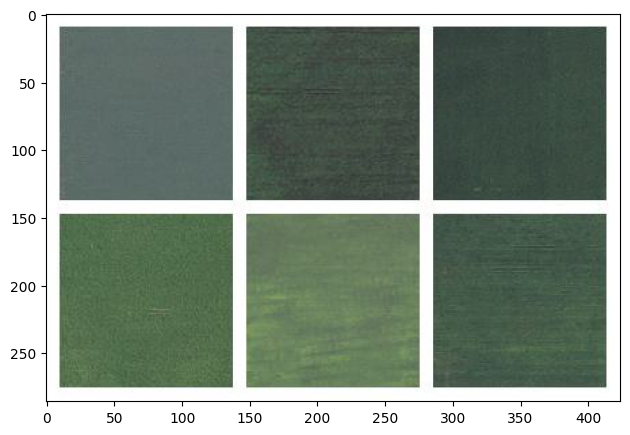

In [99]:
# Read and display the images
#images = [Image.open(path) for path in info]
#images = [[key, item[0]] for key, items in saving_response.items()]
image_number = '1043'
print('Displaying image: ', image_number)
image_file = saving_response[image_number][0]
img = Image.open(image_file)
plt.imshow(img)
plt.tight_layout()
plt.show()